In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
import warnings
warnings.filterwarnings("ignore")

<H4> LOADING DATA

In [2]:
df = pd.read_csv("housing.csv")
 
print(f"\nDataset shape : {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn data types:")
print(df.dtypes)


Dataset shape : (20640, 9)  (20,640 rows × 9 columns)

First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value  
0         322         126         8.3252              452600  
1        2401        1138         8.3014              358500  
2         496         177         7.2574              352100  
3         558         219         5.6431              341300  
4         565         259         3.8462              342200  

Column data types:
longitude             float64
latitude              float64
housing_median_age   

<H4> Data inspection

In [3]:
print("\n── Missing Values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])


── Missing Values ──
                Missing Count  Missing %
total_bedrooms            207        1.0


In [4]:
print("\n── Descriptive Statistics ──")
print(df.describe().T.to_string())


── Descriptive Statistics ──
                      count           mean            std         min          25%          50%           75%          max
longitude           20640.0    -119.569704       2.003532   -124.3500    -121.8000    -118.4900    -118.01000    -114.3100
latitude            20640.0      35.631861       2.135952     32.5400      33.9300      34.2600      37.71000      41.9500
housing_median_age  20640.0      28.639486      12.585558      1.0000      18.0000      29.0000      37.00000      52.0000
total_rooms         20640.0    2635.763081    2181.615252      2.0000    1447.7500    2127.0000    3148.00000   39320.0000
total_bedrooms      20433.0     537.870553     421.385070      1.0000     296.0000     435.0000     647.00000    6445.0000
population          20640.0    1425.476744    1132.462122      3.0000     787.0000    1166.0000    1725.00000   35682.0000
households          20640.0     499.539680     382.329753      1.0000     280.0000     409.0000     605.00000

In [5]:
print("\n── Duplicate rows ──")
print(f"Duplicates: {df.duplicated().sum()}")


── Duplicate rows ──
Duplicates: 0


<H4> Exploratory Data Analysis

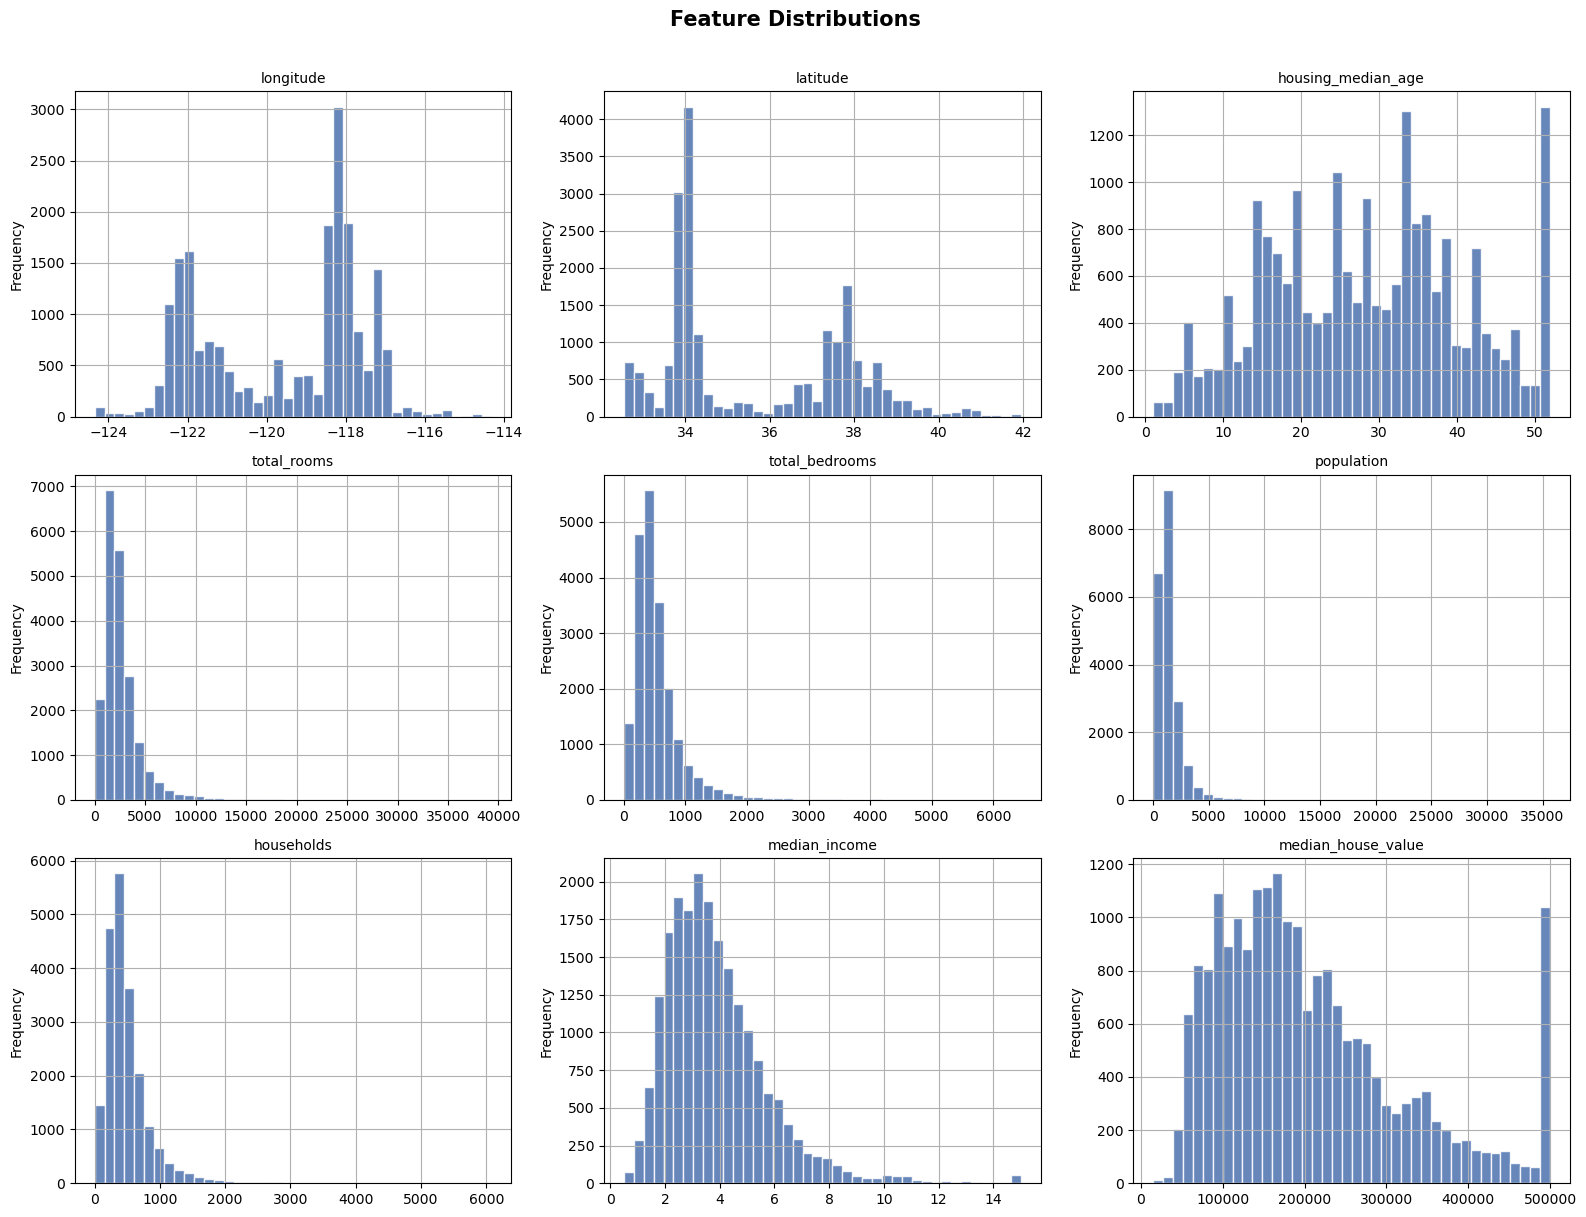

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
 
for ax, col in zip(axes.flatten(), df.columns):
    df[col].hist(bins=40, ax=ax, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
 
plt.tight_layout()
plt.show()

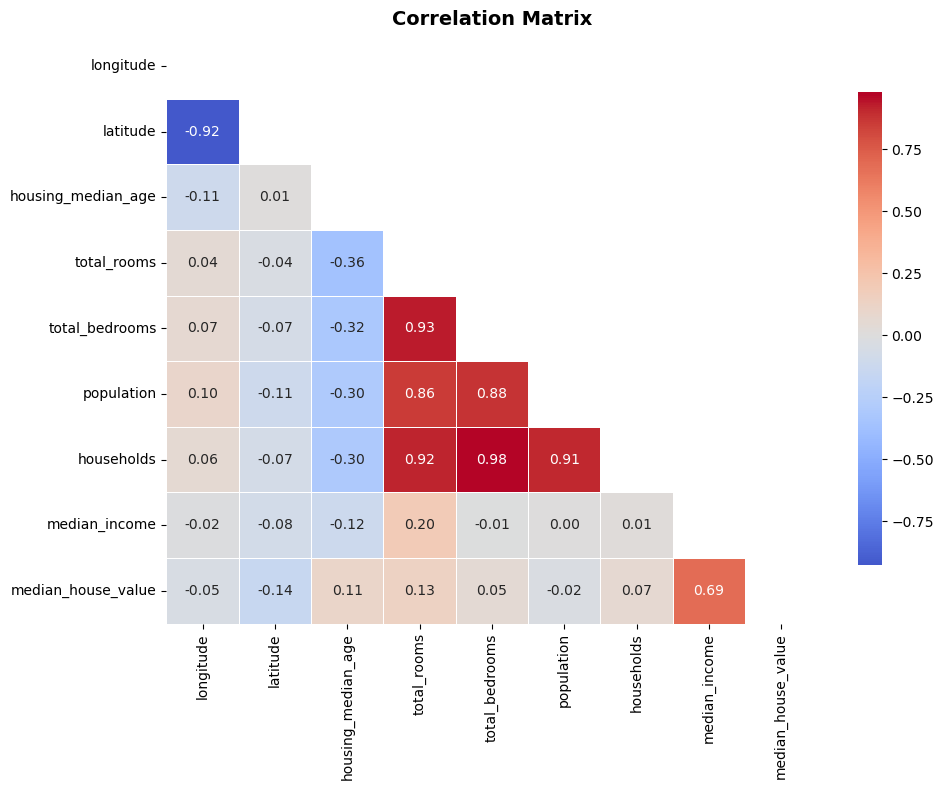

In [7]:
# correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
# Print top correlations with target
print("\n── Correlations with median_house_value ──")
print(corr["median_house_value"].sort_values(ascending=False).to_string())


── Correlations with median_house_value ──
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160


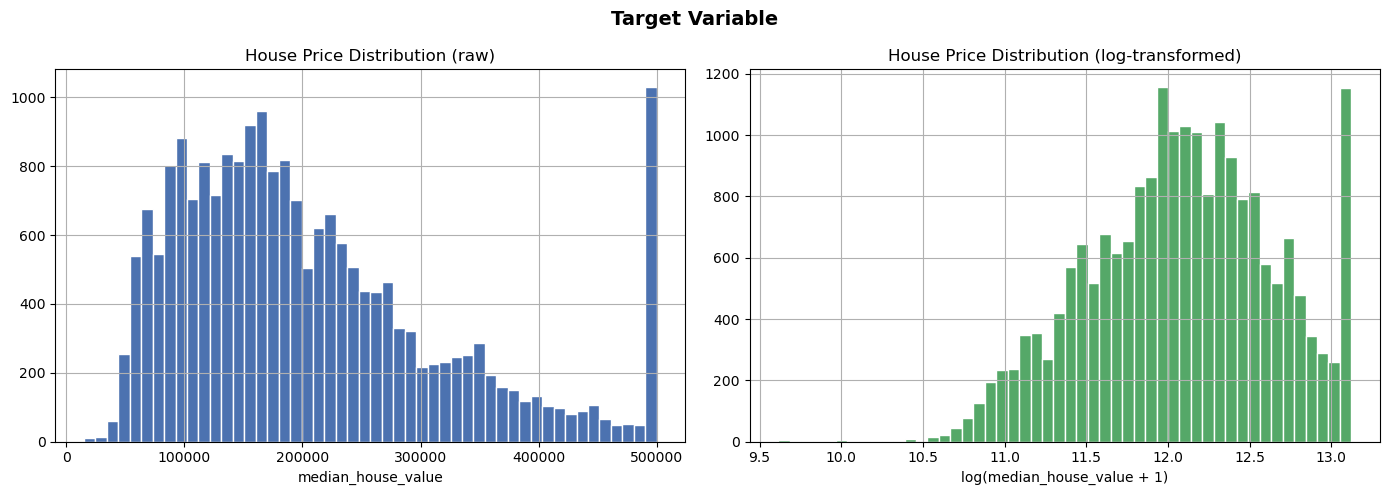

In [9]:
#  Target variable distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["median_house_value"].hist(bins=50, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("House Price Distribution (raw)")
axes[0].set_xlabel("median_house_value")
 
np.log1p(df["median_house_value"]).hist(bins=50, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("House Price Distribution (log-transformed)")
axes[1].set_xlabel("log(median_house_value + 1)")
 
plt.suptitle("Target Variable", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

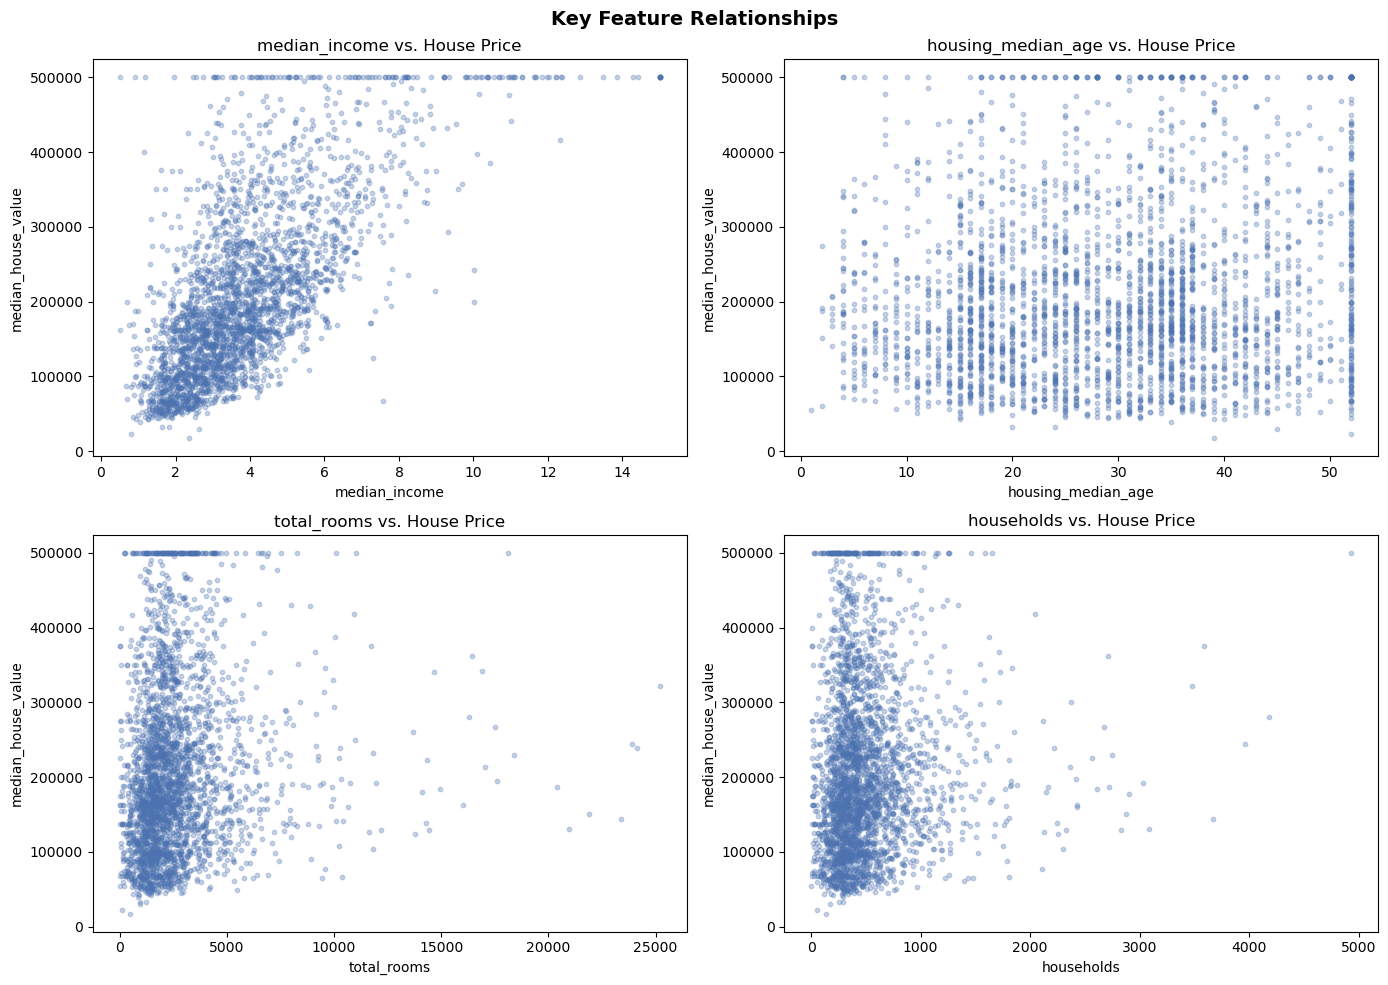

In [10]:
#  Scatter plots: top features vs target 
top_features = ["median_income", "housing_median_age", "total_rooms", "households"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
for ax, feat in zip(axes.flatten(), top_features):
    sample = df.sample(3000, random_state=42)
    ax.scatter(sample[feat], sample["median_house_value"],
               alpha=0.3, s=10, color="#4C72B0")
    ax.set_xlabel(feat)
    ax.set_ylabel("median_house_value")
    ax.set_title(f"{feat} vs. House Price")
 
plt.suptitle("Key Feature Relationships", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

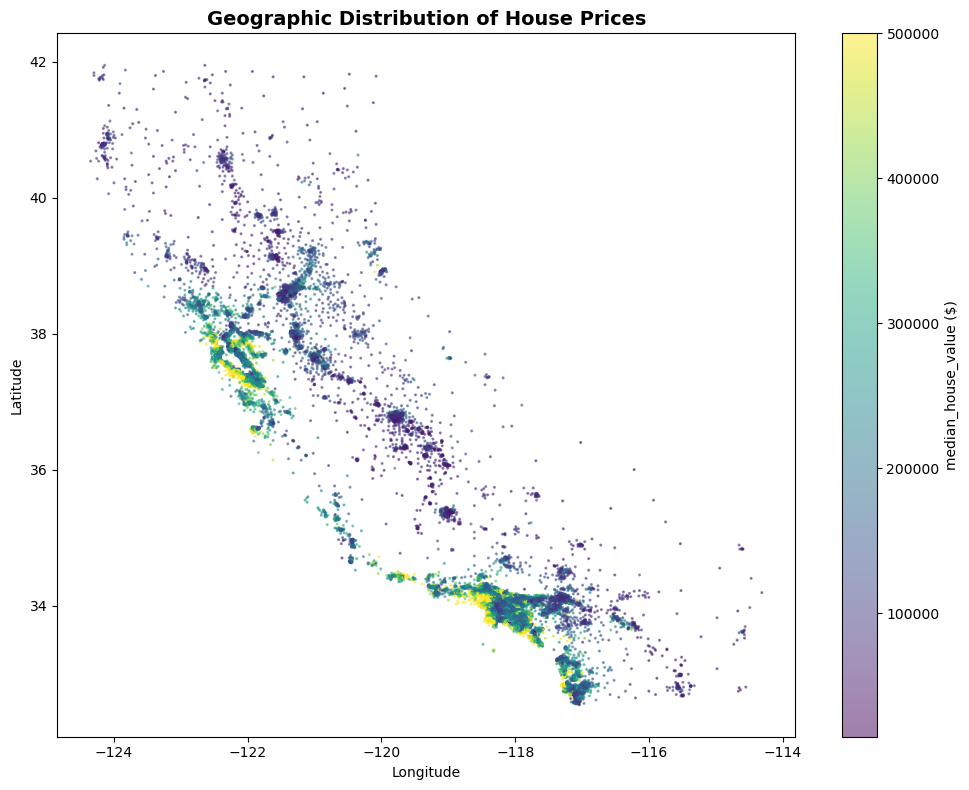

In [11]:
# Geographic heat-map 
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df["longitude"], df["latitude"],
                     c=df["median_house_value"], cmap="viridis",
                     s=1.5, alpha=0.5)
plt.colorbar(scatter, ax=ax, label="median_house_value ($)")
ax.set_title("Geographic Distribution of House Prices", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

<H4> Feature engineering

In [12]:
df_fe = df.copy()

In [13]:
# Per-household ratios — more meaningful than raw totals
df_fe["rooms_per_household"]    = df_fe["total_rooms"]    / df_fe["households"]
df_fe["bedrooms_per_room"]      = df_fe["total_bedrooms"]  / df_fe["total_rooms"]
df_fe["population_per_household"] = df_fe["population"]   / df_fe["households"]

In [14]:
# Log-transform the heavily right-skewed target
df_fe["log_price"] = np.log1p(df_fe["median_house_value"])
 
print("New engineered features:")
print(df_fe[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe().T.to_string())

New engineered features:
                            count      mean        std       min       25%       50%       75%          max
rooms_per_household       20640.0  5.429000   2.474173  0.846154  4.440716  5.229129  6.052381   141.909091
bedrooms_per_room         20433.0  0.213039   0.057983  0.100000  0.175427  0.203162  0.239821     1.000000
population_per_household  20640.0  3.070655  10.386050  0.692308  2.429741  2.818116  3.282261  1243.333333


<H4> Train Test split

In [16]:
TARGET = "log_price"
DROP_COLS = ["median_house_value", "log_price"]
 
X = df_fe.drop(columns=DROP_COLS)
y = df_fe[TARGET]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Features     : {X_train.shape[1]}")

Training set : 16,512 samples
Test set     : 4,128 samples
Features     : 11


<H4> Preprocessing pipelines

In [17]:
# A single pipeline: impute missing values → scale features
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
 
print("Pipeline: median imputation → standard scaling")

Pipeline: median imputation → standard scaling


<H4> Model Training and cross validation

In [18]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

In [19]:
models = {
    "Linear Regression"        : LinearRegression(),
    "Ridge Regression"         : Ridge(alpha=1.0),
    "Random Forest"            : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting"        : GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                            max_depth=4, random_state=42),
}

In [20]:
cv_results = {}
 
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_prep, y_train,
                                cv=5, scoring="r2", n_jobs=-1)
    cv_results[name] = cv_scores
    print(f"\n{name}")
    print(f"  CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Linear Regression
  CV R² : 0.6512 ± 0.0113

Ridge Regression
  CV R² : 0.6512 ± 0.0113

Random Forest
  CV R² : 0.8266 ± 0.0029

Gradient Boosting
  CV R² : 0.8353 ± 0.0018


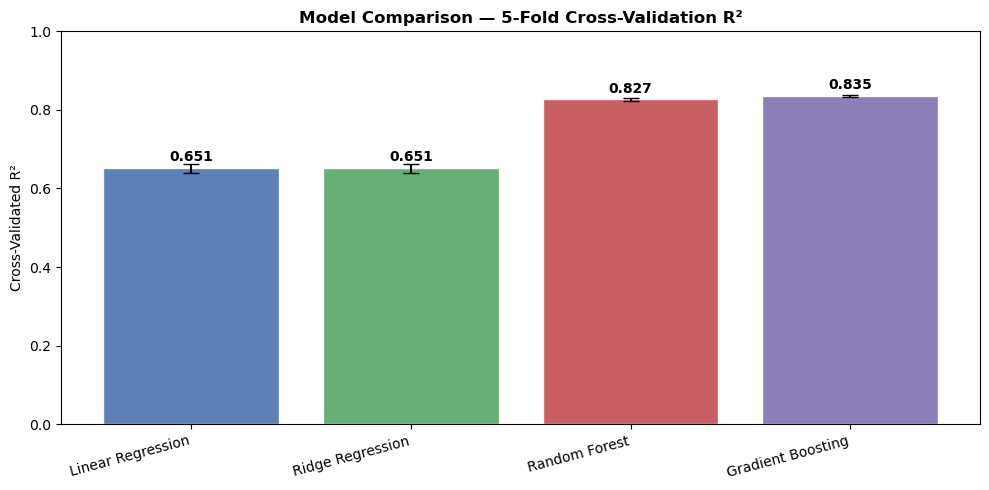

In [21]:
#  CV results bar chart 
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
 
bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, edgecolor="white", alpha=0.9)
ax.set_ylabel("Cross-Validated R²")
ax.set_title("Model Comparison — 5-Fold Cross-Validation R²", fontweight="bold")
ax.set_ylim(0, 1)
 
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{m:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
 
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

<H4> Hyperparameter tuning (Best model)

In [22]:
param_grid = {
    "n_estimators"  : [100, 200],
    "learning_rate" : [0.05, 0.1],
    "max_depth"     : [3, 4],
}
 
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(X_train_prep, y_train)
 
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_

Best parameters : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV R²      : 0.8320


<H4> Test set evaluation

In [23]:
def evaluate(name, model, X, y):
    """Evaluate in log-space, then convert back to $ for interpretability."""
    y_log_pred = model.predict(X)
 
    # Metrics in log-space
    r2   = r2_score(y, y_log_pred)
    rmse = np.sqrt(mean_squared_error(y, y_log_pred))
 
    # Convert back to dollars
    y_dollar      = np.expm1(y)
    y_pred_dollar = np.expm1(y_log_pred)
    mae_dollar    = mean_absolute_error(y_dollar, y_pred_dollar)
    rmse_dollar   = np.sqrt(mean_squared_error(y_dollar, y_pred_dollar))
 
    print(f"\n── {name} ──")
    print(f"  R²        : {r2:.4f}")
    print(f"  RMSE (log): {rmse:.4f}")
    print(f"  MAE  ($)  : ${mae_dollar:,.0f}")
    print(f"  RMSE ($)  : ${rmse_dollar:,.0f}")
    return y_log_pred

In [24]:
# Evaluate all models + best tuned model
all_models_results = {}
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    all_models_results[name] = evaluate(name, model, X_test_prep, y_test)
 
y_pred_best = evaluate("Gradient Boosting (Tuned)", best_model, X_test_prep, y_test)


── Linear Regression ──
  R²        : 0.6319
  RMSE (log): 0.3456
  MAE  ($)  : $53,044
  RMSE ($)  : $96,394

── Ridge Regression ──
  R²        : 0.6319
  RMSE (log): 0.3456
  MAE  ($)  : $53,048
  RMSE ($)  : $96,398

── Random Forest ──
  R²        : 0.8278
  RMSE (log): 0.2364
  MAE  ($)  : $31,987
  RMSE ($)  : $51,548

── Gradient Boosting ──
  R²        : 0.8316
  RMSE (log): 0.2338
  MAE  ($)  : $32,200
  RMSE ($)  : $49,708

── Gradient Boosting (Tuned) ──
  R²        : 0.8316
  RMSE (log): 0.2338
  MAE  ($)  : $32,200
  RMSE ($)  : $49,708


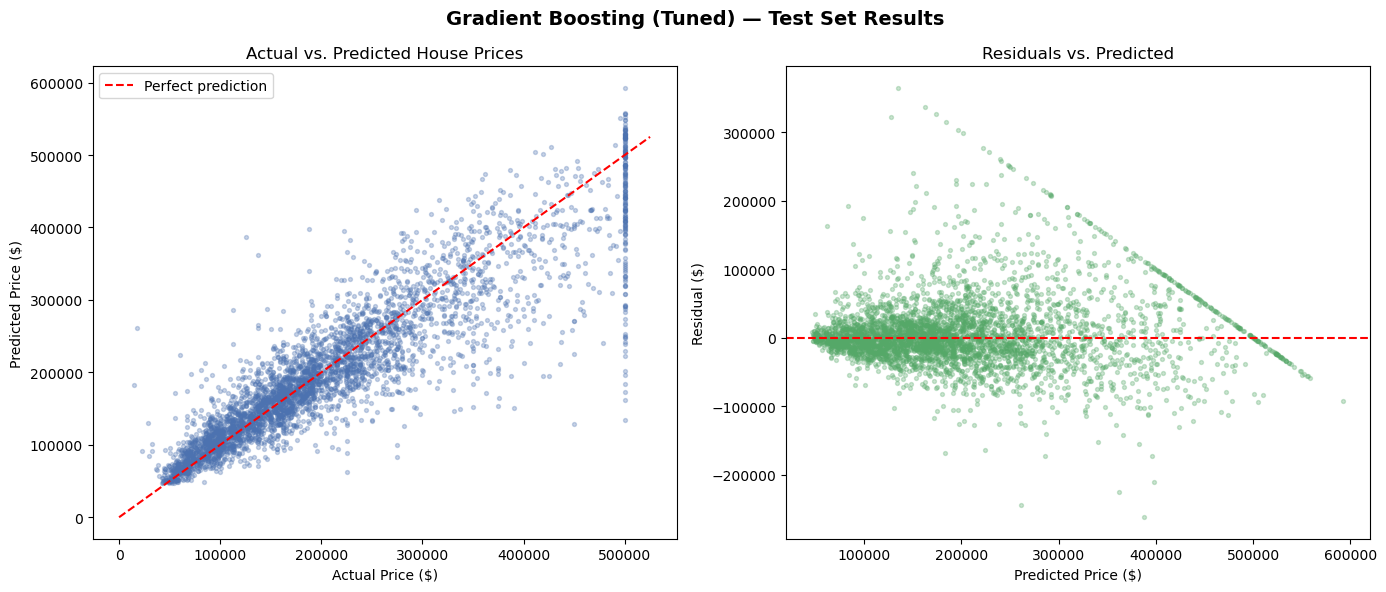

In [26]:
#  Actual vs Predicted plot 
y_dollar      = np.expm1(y_test)
y_pred_dollar = np.expm1(y_pred_best)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Scatter
axes[0].scatter(y_dollar, y_pred_dollar, alpha=0.3, s=8, color="#4C72B0")
lims = [0, y_dollar.max() * 1.05]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Actual vs. Predicted House Prices")
axes[0].legend()
 
# Residuals
residuals = y_dollar - y_pred_dollar
axes[1].scatter(y_pred_dollar, residuals, alpha=0.3, s=8, color="#55A868")
axes[1].axhline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title("Residuals vs. Predicted")
 
plt.suptitle("Gradient Boosting (Tuned) — Test Set Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

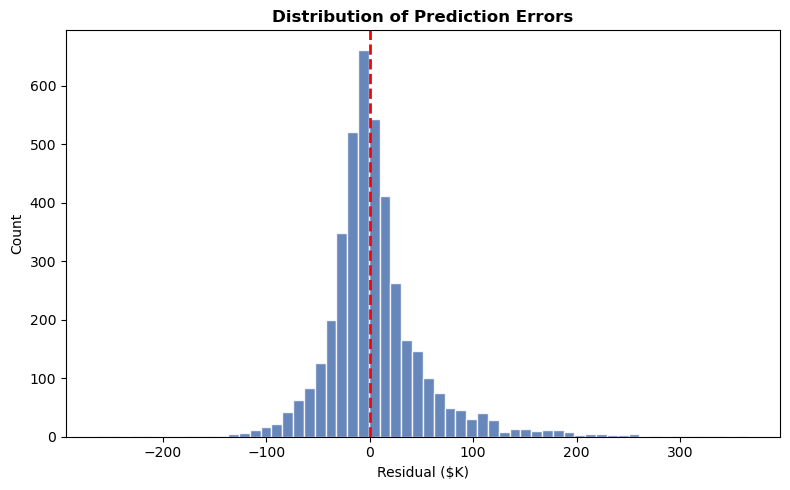

In [27]:
#  Residuals distribution 
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals / 1000, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", lw=2, ls="--")
ax.set_xlabel("Residual ($K)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Prediction Errors", fontweight="bold")
plt.tight_layout()
plt.show()

<H4> Feature importance

In [28]:
importances = best_model.feature_importances_
feat_names  = X.columns.tolist()
importance_df = (
    pd.DataFrame({"Feature": feat_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
 
print(importance_df.to_string(index=False))

                 Feature  Importance
           median_income    0.545209
               longitude    0.136926
                latitude    0.134659
population_per_household    0.090735
       bedrooms_per_room    0.029599
     rooms_per_household    0.027234
      housing_median_age    0.022071
             total_rooms    0.004663
          total_bedrooms    0.003684
              households    0.002801
              population    0.002419


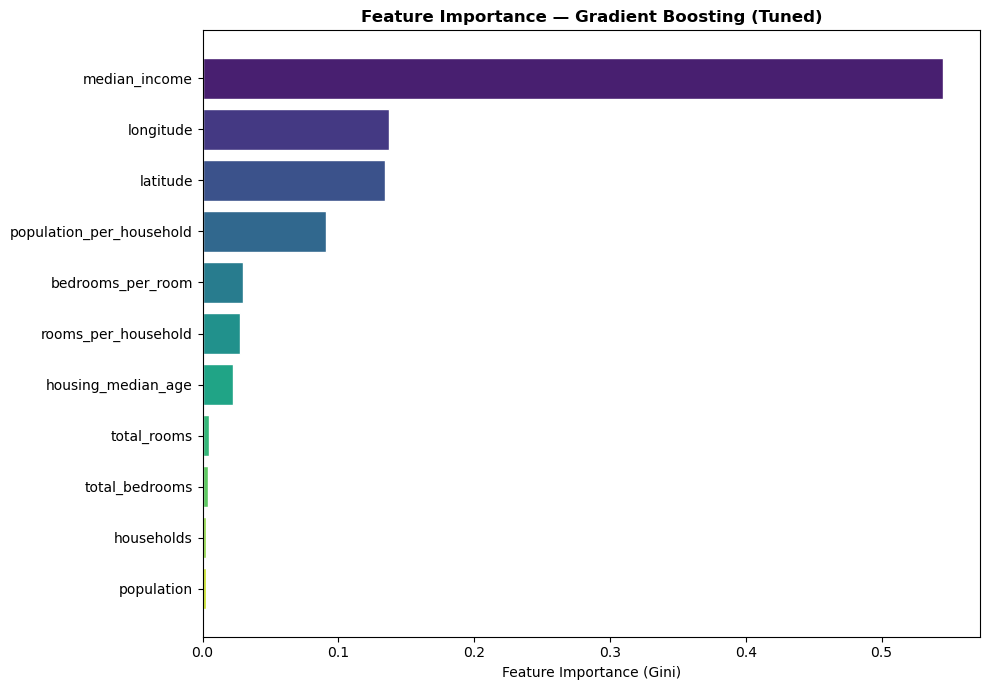

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = sns.color_palette("viridis", len(importance_df))[::-1]
ax.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1],
        color=colors_bar, edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Feature Importance — Gradient Boosting (Tuned)", fontweight="bold")
plt.tight_layout()
plt.show()